## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization_logreg import LogRegScalarization

## Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
PREFIX_SAVE_IMAGE = 'images/2_objs'

In [6]:
data = pd.read_csv('dataset/compas_onerace.csv')
data = data.drop('Unnamed: 0', axis=1)

fair_feature = 'not_white'
pred_feature = 'Two_yr_Recidivism'

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


### Dataset Analysis

In [7]:
raw_data = pd.read_csv('dataset/compas-scores-two-years.csv')
#raw_data.head(3)

In [8]:
print(f'Dataset Size    : {len(data)}')
print(f'Train Set Size  : {len(X_train)}')
print(f'Raw dataset Size: {len(raw_data)}')

Dataset Size    : 6172
Train Set Size  : 3086
Raw dataset Size: 7214


In [9]:
print(f'Dataset Features    : {len(data.columns)}')
print(f'Raw Dataset Features: {len(raw_data.columns)}')

Dataset Features    : 7
Raw Dataset Features: 53


In [10]:
datasets = [('Dataset', data['not_white']),
            ('Train Set', X_train['not_white']),
            ('Test Set', X_test['not_white'])]

print(f'{'Set':<10} | {'White (count/%)':>15} | {'Non-White (count/%)':>15} | {'Total':>8}')
print('-' * 62)

for name, col in datasets:
    counts = col.value_counts()
    total = len(col)
    white = counts.get(0, 0)
    non_white = counts.get(1, 0)
    white_pct = white / total * 100
    non_white_pct = non_white / total * 100
    print(f'{name:<10} | {white:>6} ({white_pct:>5.1f}%) | {non_white:>10} ({non_white_pct:>5.1f}%) | {total:>8}')

Set        | White (count/%) | Non-White (count/%) |    Total
--------------------------------------------------------------
Dataset    |   2103 ( 34.1%) |       4069 ( 65.9%) |     6172
Train Set  |   1051 ( 34.1%) |       2035 ( 65.9%) |     3086
Test Set   |   1052 ( 34.1%) |       2034 ( 65.9%) |     3086


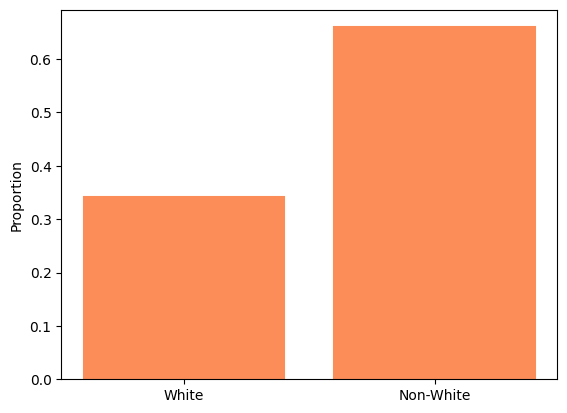

In [11]:
import matplotlib.pyplot as plt

#plt.figure(figsize=(6,4))
colors = ['#fc8d59', '#fc8d59']

counts = X_train['not_white'].value_counts(normalize=True).sort_index().to_list()

plt.bar([0, 1], counts, color=colors, edgecolor='#fc8d59', linewidth=1.5)
plt.xticks([0,1], ['White','Non-White'], rotation=0)
#plt.title('Distribution of Race in Training Set (%)')
plt.ylabel('Proportion')
plt.savefig(f"images/compas_analysis.pdf", bbox_inches="tight")
plt.show()

### Suppress ConvergenceWarning from scikit-learn's LogisticRegression.

In [12]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from scikit-learn's LogisticRegression.
# These warnings indicate that the solver did not converge within the
# default number of iterations. In this project we are aware of this 
# behavior but choose not to address it here, as it does not affect 
# the focus of our experiments. Therefore, the warnings are silenced 
# to avoid cluttering the logs and console output.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [13]:
#import logging
#
#logging.captureWarnings(True)
#logging.getLogger('py.warnings').setLevel(logging.ERROR)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * NISE
    * MONISE
    * Random Weights

In [14]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}

num_objs = 2
objectives_names = ['White', 'Non-White']
results = {}

In [15]:
# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

In [16]:
# Logistic Regression Config for MOO
tol = 10**-8
max_iter = 10

In [17]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(
    num_objs=num_objs,
    X=X_train, 
    y=y_train, 
    fair_feat=fair_feature,
    #tol=tol, max_iter=max_iter
)
equal.optimize(np.array([0.5, 0.5]))

In [18]:
def machine_optimize(method, lb_estimate=0.01):
    w_scalar = LogRegScalarization(
        num_objs=num_objs, 
        X=X_train, 
        y=y_train,
        fair_feat=fair_feature,
        tol=tol,
        max_iter=max_iter, 
        lower_bound_estimate=lb_estimate  # Options: 'zero', 'lipschitz', or a float value
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    'moopt': moopt,
                    'objectives': objs,
                    'models': get_models(moopt),
                    'hypervolume': hypervolume_values
                }

In [19]:
def plot_frontier(method, color='#d73027'):
    title='Loss Trade-offs for White and Non-White Person'
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                subset=equal.objs,
                color=color,
                fontsize=26,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [20]:
method = 'mola'
machine_optimize(method=method)

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

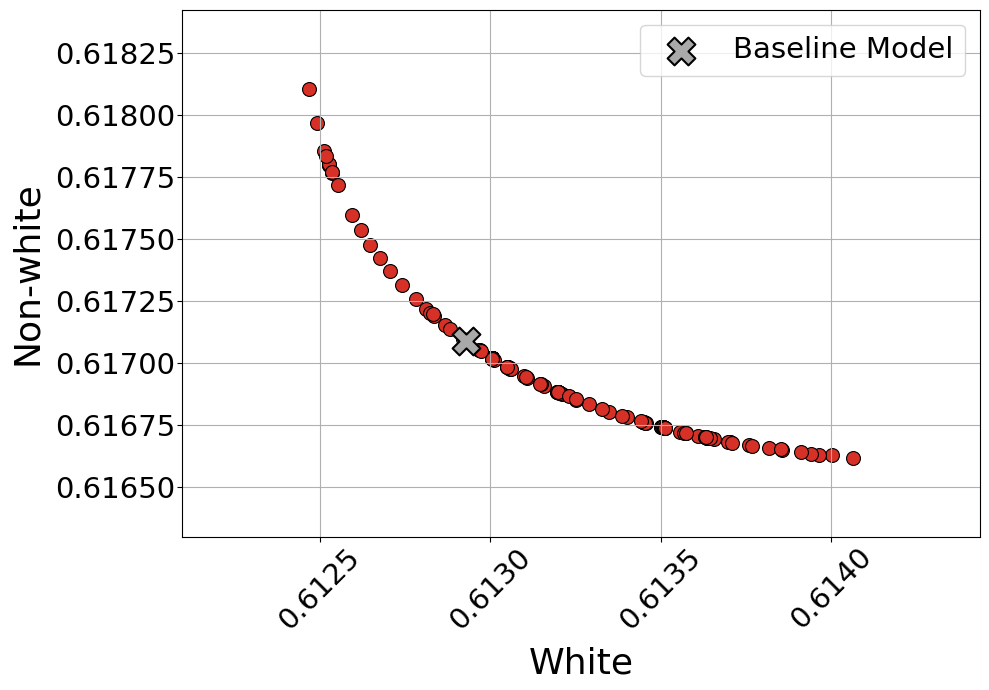

In [21]:
plot_frontier('mola', color='#d73027')

### MOLA with gradient

In [22]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

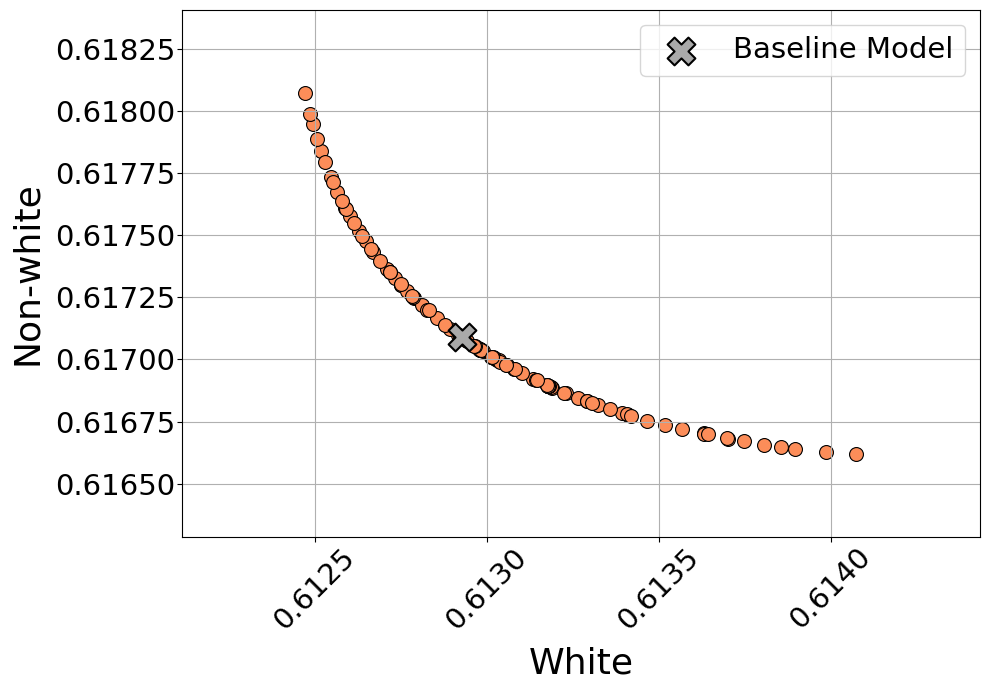

In [23]:
plot_frontier(f'mola_grad', color='#fc8d59')

### Ramdon Weighted Sum

In [24]:
method = 'random_weights'
machine_optimize(method=method)

### NISE

In [25]:
method = 'nise'
machine_optimize(method=method)

/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warnings.warn('Not optimal solver or nonconvex problem')
/home/lineccsa/mestrado/machinemoo/machinemoo/moo/nise.py:381: UserWarning: Not optimal solver or nonconvex problem
  warning

### MONISE

In [26]:
method = 'monise'
machine_optimize(method=method)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 3000x1400 with 0 Axes>

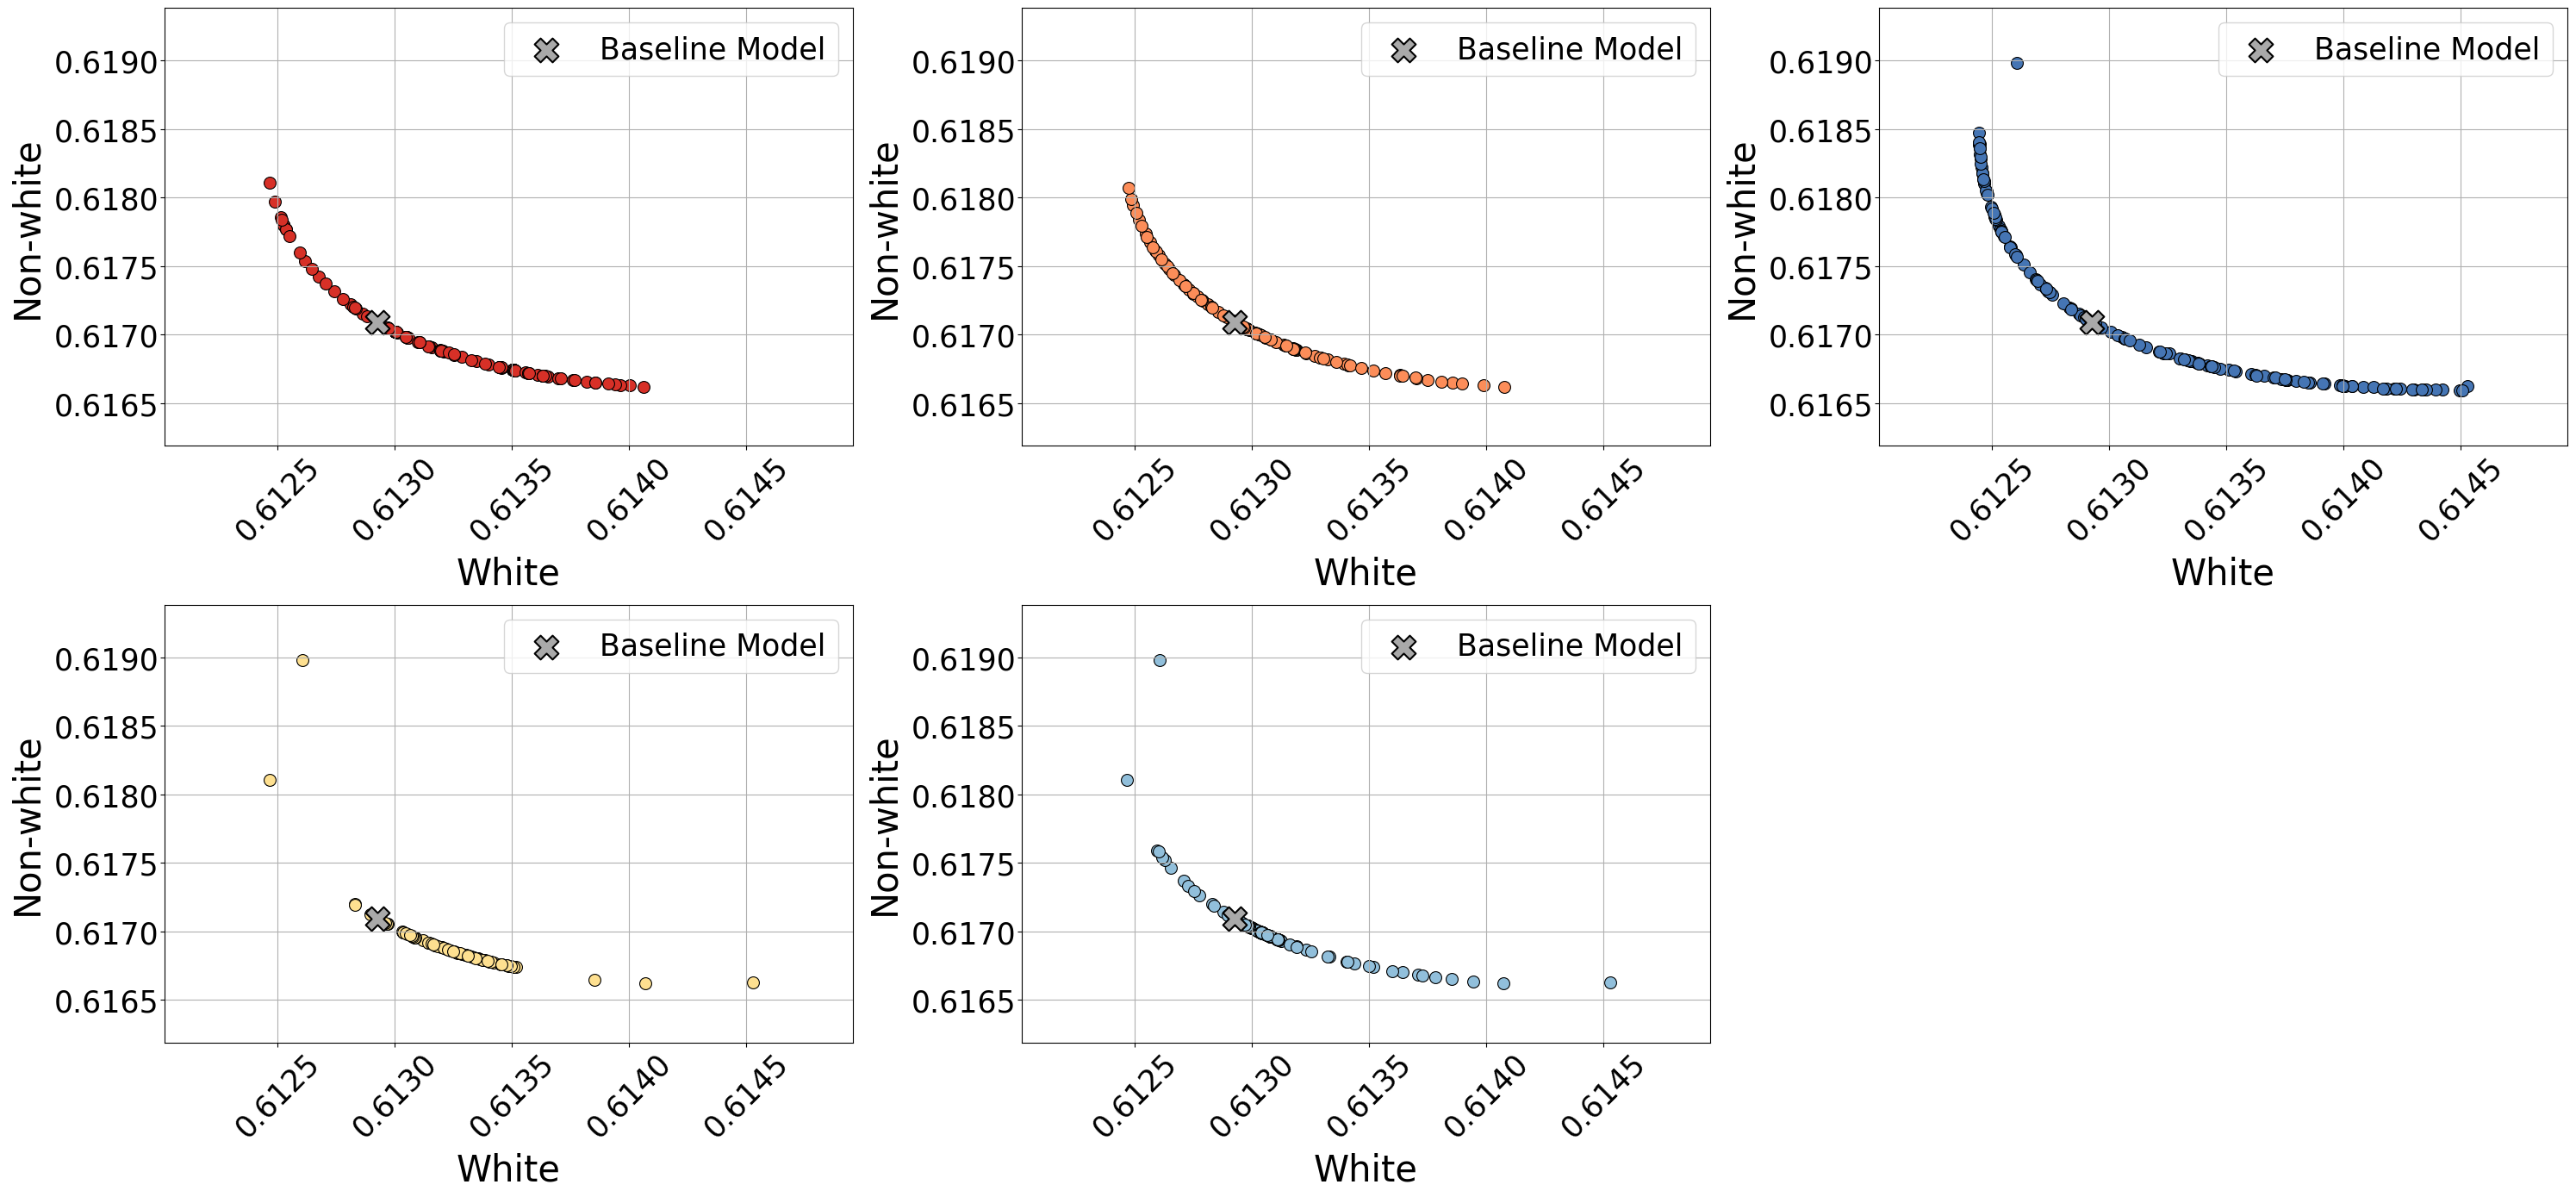

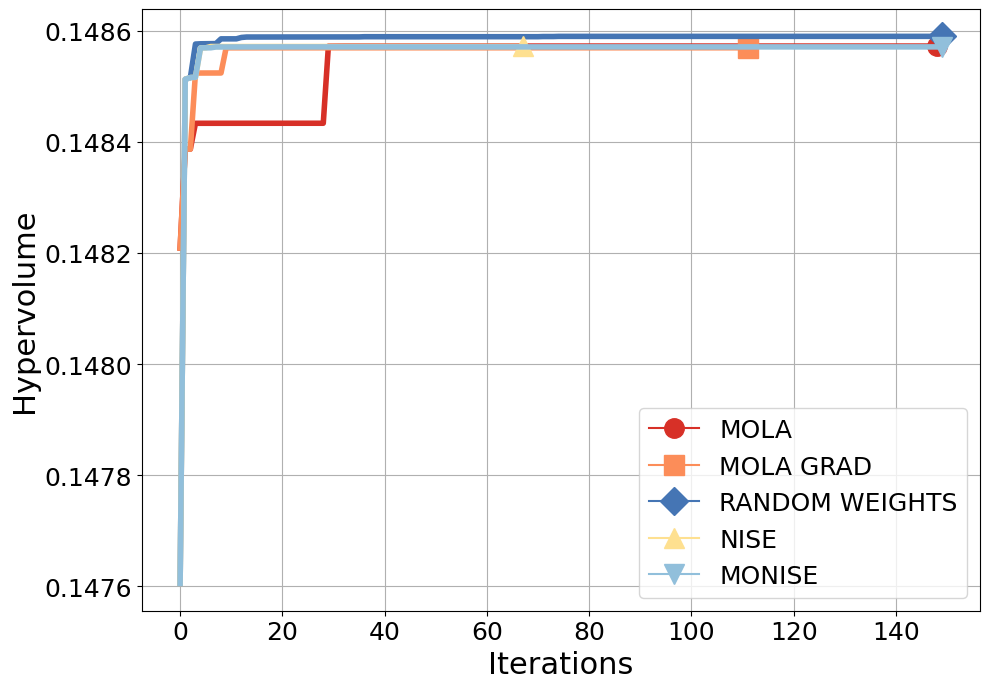

In [27]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if ('objectives' in res)
    }

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            subset=equal.objs,
            fontsize=30,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

### Non-dominated Solutions Analysis

In [29]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

In [30]:
## MOLA get only non dominated solutions
print(f'Number of non-dominated solutions with MOLA        : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD   : {len(results['mola_grad']['objectives'])}')

Number of non-dominated solutions with MOLA        : 141
Number of non-dominated solutions with MOLA GRAD   : 108


In [31]:
non_dominated_dict = {}

for method, res in results.items():
    if 'objectives' not in res:
        continue 

    solutions = res['objectives']

    # Indetify non-dominated solutions index
    nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)
    non_dominated_solutions = solutions[nd_indices]

    # Guarda no dicionário
    non_dominated_dict[method] = non_dominated_solutions

    print(f'Number of non-dominated solutions with {method.upper():<15}: {len(non_dominated_solutions)}')

Number of non-dominated solutions with MOLA           : 141
Number of non-dominated solutions with MOLA_GRAD      : 108
Number of non-dominated solutions with RANDOM_WEIGHTS : 139
Number of non-dominated solutions with NISE           : 64
Number of non-dominated solutions with MONISE         : 147


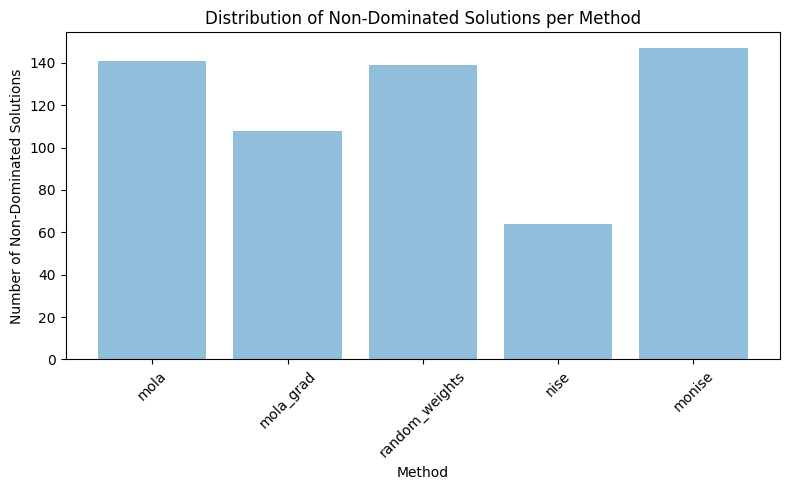

In [32]:
import matplotlib.pyplot as plt

# Number of non dominated solutions per method
nd_counts = {method: len(sols) for method, sols in non_dominated_dict.items()}

# bar plot
plt.figure(figsize=(8, 5))
plt.bar(nd_counts.keys(), nd_counts.values(), color='#91bfdb')
plt.xlabel('Method')
plt.ylabel('Number of Non-Dominated Solutions')
plt.title('Distribution of Non-Dominated Solutions per Method')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

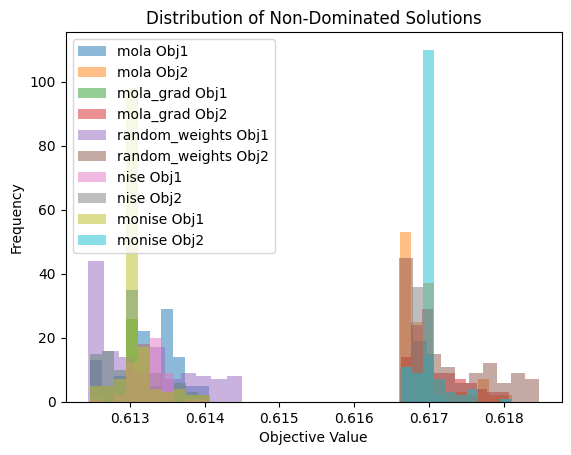

In [33]:
for method, sols in non_dominated_dict.items():
    plt.hist(sols[:,0], alpha=0.5, label=f'{method} Obj1')
    plt.hist(sols[:,1], alpha=0.5, label=f'{method} Obj2')

plt.xlabel('Objective Value')
plt.ylabel('Frequency')
plt.title('Distribution of Non-Dominated Solutions')
plt.legend()
plt.show()

### Ensemble

In [34]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from machinemoo.analysis.ensembles import voting_ensemble, weighted_soft_voting, max_rule

In [ ]:
lambd = math.exp(-100)
clf = LogisticRegression()

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
auc_logreg = roc_auc_score(y_test, pred)

In [ ]:
# Logistic Regression Single Objctive
print(f'Logistic Regression Accuracy: {auc_logreg*100:.2f}%')

Logistic Regression Accuracy: 65.81%


In [37]:
def get_auc_weights(models, X_val, y_val):
    scores = [roc_auc_score(y_val, model.predict(X_val)) for model in models]
    weights = np.array(scores) / np.sum(scores)  # normalize
    return weights

In [39]:
## Aggregation with trained models obtained with MOO
ensembles = {}
for method in results.keys():
    y_pred_voting_hard = voting_ensemble(
        models=results[method]['models'], 
        X=X_test,  
        voting='hard',
        task='classification'
    )
    
    acc_voting_hard = roc_auc_score(y_test, y_pred_voting_hard)
    
    ## soft
    y_pred_voting_soft, _ = voting_ensemble(
        models=results[method]['models'], 
        X=X_test,  
        voting='soft',
        task='classification'
    )
    
    acc_voting_soft = roc_auc_score(y_test, y_pred_voting_soft)

    ## weighted
    y_pred_weighted, _ = weighted_soft_voting(
        models=results[method]['models'], 
        X=X_test,  
        weights=get_auc_weights(results[method]['models'], X_train, y_train)
    )
    
    acc_weighted = roc_auc_score(y_test, y_pred_weighted)

    ## max rule
    y_pred_max_rule, _ = max_rule(
        models=results[method]['models'], 
        X=X_test,  
    )
    
    acc_max_rule = roc_auc_score(y_test, y_pred_max_rule)
    
    ensembles[method] = {
        'acc_voting_hard': acc_voting_hard,
        'acc_voting_soft': acc_voting_soft,
        'acc_weighted': acc_weighted,
        'acc_max_rule': acc_max_rule,
        #'y_pred': y_pred_voting_hard
    }

In [40]:
for method, ensemble in ensembles.items():
    print(f'  AUC hard     {method.upper():<15}: {ensemble['acc_voting_hard']*100:6.2f}%')
    print(f'  AUC soft     {method.upper():<15}: {ensemble['acc_voting_soft']*100:6.2f}%')
    print(f'  AUC weighted {method.upper():<15}: {ensemble['acc_weighted']*100:6.2f}%')
    print(f'  AUC max rule {method.upper():<15}: {ensemble['acc_max_rule']*100:6.2f}%')

  AUC hard     MOLA           :  65.96%
  AUC soft     MOLA           :  65.96%
  AUC weighted MOLA           :  65.96%
  AUC max rule MOLA           :  65.96%
  AUC hard     MOLA_GRAD      :  65.81%
  AUC soft     MOLA_GRAD      :  65.81%
  AUC weighted MOLA_GRAD      :  65.81%
  AUC max rule MOLA_GRAD      :  65.81%
  AUC hard     RANDOM_WEIGHTS :  65.81%
  AUC soft     RANDOM_WEIGHTS :  65.81%
  AUC weighted RANDOM_WEIGHTS :  65.81%
  AUC max rule RANDOM_WEIGHTS :  65.81%
  AUC hard     NISE           :  65.81%
  AUC soft     NISE           :  65.81%
  AUC weighted NISE           :  65.81%
  AUC max rule NISE           :  65.81%
  AUC hard     MONISE         :  65.81%
  AUC soft     MONISE         :  65.81%
  AUC weighted MONISE         :  65.81%
  AUC max rule MONISE         :  65.81%


In [41]:
equal_model = equal.x
predictions = equal_model.predict(X_test)
auc_equal = roc_auc_score(y_test, predictions)
print(f'AUC of Logistic Regression with Equal Weights {auc_equal*100:.2f}%')

AUC of Logistic Regression with Equal Weights 65.81%


### Best Solution Criteria - Analysis with MOLA

In [42]:
from machinemoo.analysis.decision import select_lowest_median_solution, select_weighted_solution

In [43]:
mola = results['mola']

In [44]:
# Objective weights: higher values increase priority, balance defined by the weight vector
weights_vector = [2, 6]
solution_weighted = select_weighted_solution(mola['objectives'], mola['models'], weights_vector)
print(solution_weighted)

{'index': 33, 'score': 0.6159310295688948, 'objectives': [0.6135578026793101, 0.6167221051987564], 'model': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}


/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

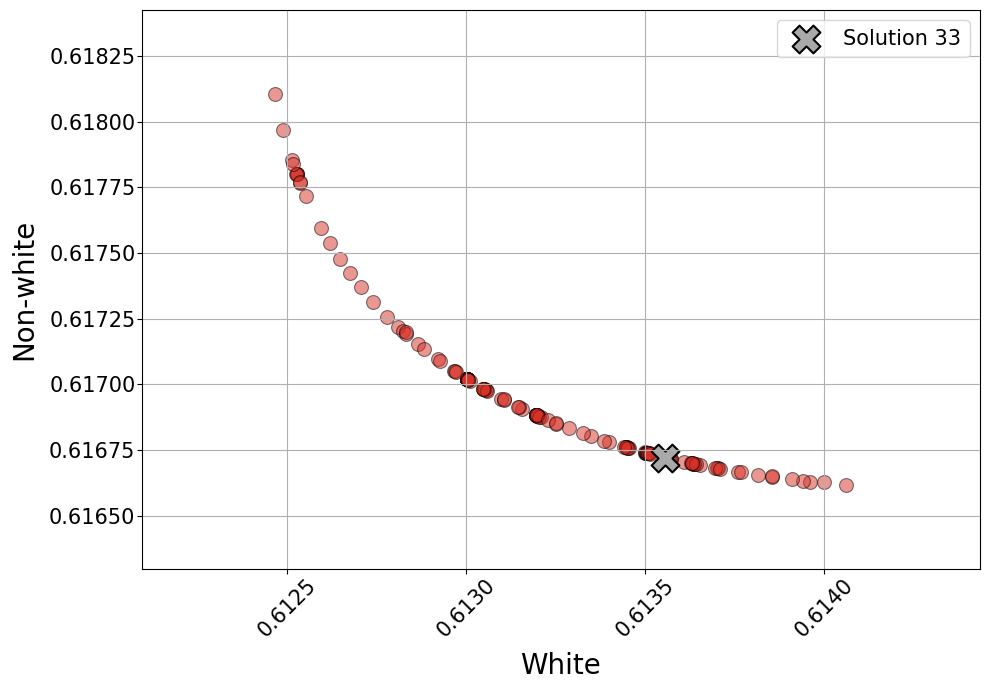

In [45]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            #title=title,
            fontsize=20,
            figsize=(10,7),
            subset=solution_weighted['objectives'],
            subset_label=f'Solution {solution_weighted['index']}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_weighted.pdf',
            alpha=0.5,
            s_factor=2
            )

In [46]:
print(type(mola['objectives']))
print(len(mola['objectives']))
print(type(mola['objectives'][0]), mola['objectives'][0])

<class 'numpy.ndarray'>
141
<class 'numpy.ndarray'> [0.61351258 0.61673734]


In [47]:
# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0
solution_median = select_lowest_median_solution(objectives=mola['objectives'], models=mola['models'])
print(solution_median)

# Selects the solution with the lowest median across objectives, ignoring any objectives equal to 0.0 
# and values above a predefined threshold.
# Thresholds can be set per objective using a dictionary: {objective_index: max_value}.
# Here, the 1st objective has a threshold of 6128.
solution_median_threshold = select_lowest_median_solution(
    objectives=mola['objectives'],
    models=mola['models'],
    #objective_thresholds={0: 0.6125}
    )
print(solution_median_threshold)

{'index': 37, 'score': 0.6150081192034287, 'objectives': [0.6129209167439164, 0.6170953216629411], 'models': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}
{'index': 37, 'score': 0.6150081192034287, 'objectives': [0.6129209167439164, 0.6170953216629411], 'models': LogisticRegression(C=2.688117141816135e+43, max_iter=10, tol=1e-08,
                   warm_start=True)}


In [48]:
# Analysis three solutions
subset = [
    solution_weighted['objectives'],
    solution_median['objectives'],
    solution_median_threshold['objectives']
]

labels = [
    f'Solution {solution_weighted['index']:<3} - Weighted',
    f'Solution {solution_median['index']:<4} - Median',
    f'Solution {solution_median_threshold['index']:<4} - Median Threshold'
]
markers = ['X', 'o', 's']

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

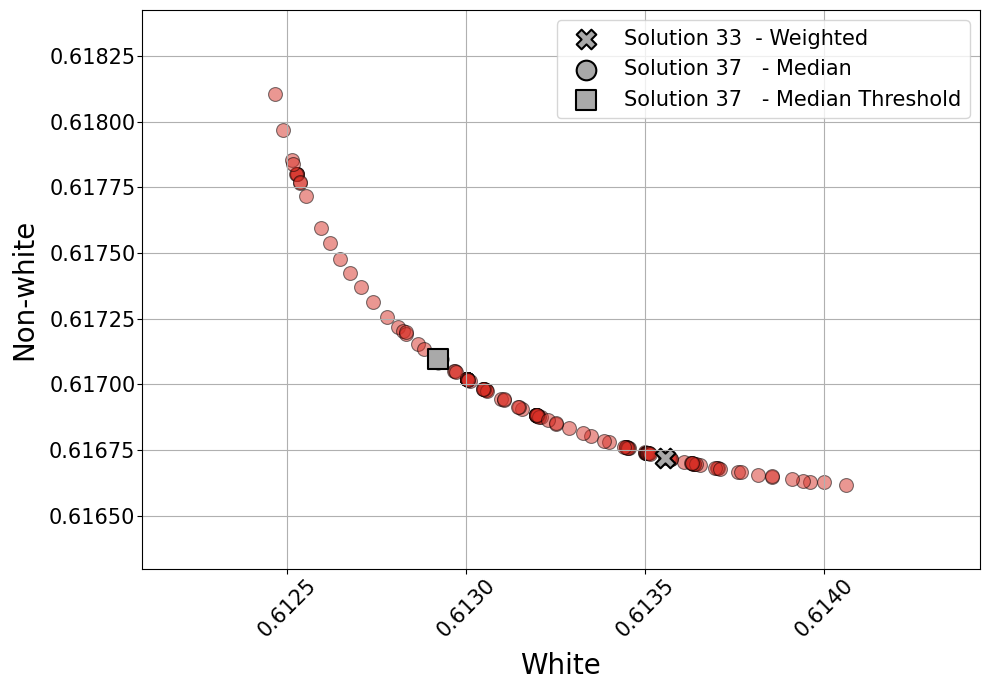

In [55]:
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=objectives_names, 
            # title=title,
            fontsize=20,
            figsize=(10,7),
            subset=subset,
            subset_label=labels,
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_decision.pdf',
            alpha=0.5,
            s_factor=2,
            subset_marker=markers
            )

## Other Convergence Metrics

In [56]:
# With pymoo
from pymoo.indicators.igd import IGD
from pymoo.indicators.gd_plus import GDPlus
#from pymoo.indicators.spacing import Spacing

# Example: reference_front is the true or merged Pareto front
# solutions is the nondominated set obtained by a method

In [57]:
all_solutions = np.vstack([results['mola']['objectives'], results['mola_grad']['objectives'], results['nise']['objectives'], results['monise']['objectives'], results['random_weights']['objectives']])
nds = NonDominatedSorting().do(solutions, only_non_dominated_front=True)
reference_front = all_solutions[nds]

In [60]:
igd = IGD(reference_front)
print(f'{'Method':<13} | {'Inverted Generational Distance':>15}')
print('-' * 46)

for method, res in results.items():
    if 'objectives' in res:
        spacing = igd.do(res['objectives'])
        print(f'{method.upper():<14} | {spacing:>13.2e}')

Method        | Inverted Generational Distance
----------------------------------------------
MOLA           |      9.17e-07
MOLA_GRAD      |      9.54e-06
RANDOM_WEIGHTS |      8.55e-06
NISE           |      5.91e-05
MONISE         |      2.22e-05


In [62]:
gd = GDPlus(reference_front)

print(f'{'Method':<13} | {'Generational Distance Plus':>15}')
print('-' * 42)

for method, res in results.items():
    if 'objectives' in res:
        spacing = gd.do(res['objectives'])
        print(f'{method.upper():<14} | {spacing:>13.2e}')

Method        | Generational Distance Plus
------------------------------------------
MOLA           |      2.75e-08
MOLA_GRAD      |      5.95e-06
RANDOM_WEIGHTS |      6.01e-05
NISE           |      2.39e-05
MONISE         |      1.31e-05


# Only for dissertation

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

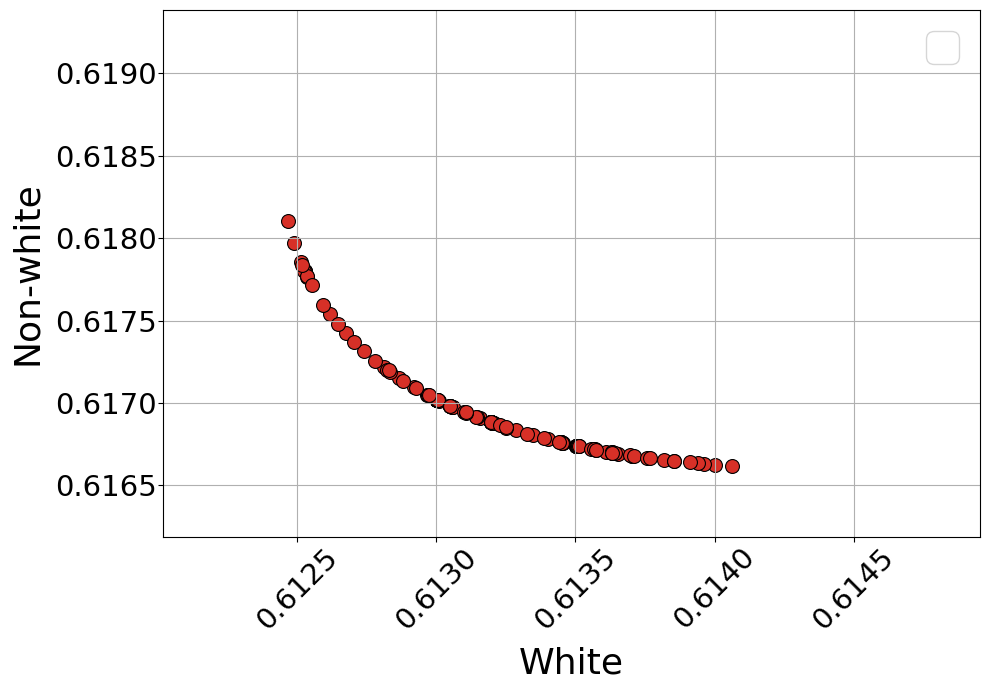

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

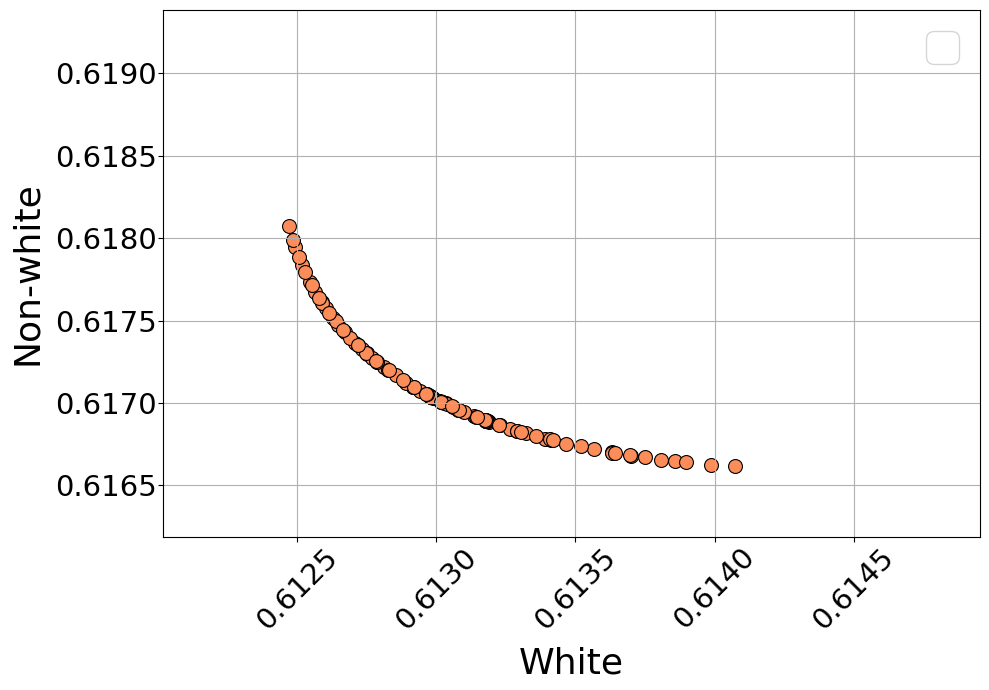

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

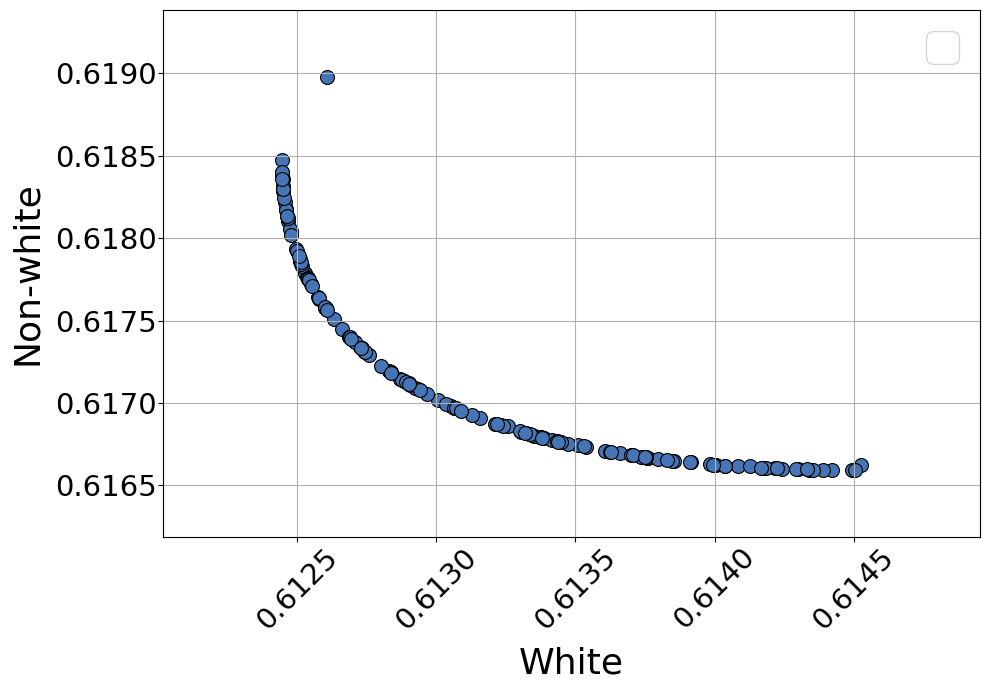

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

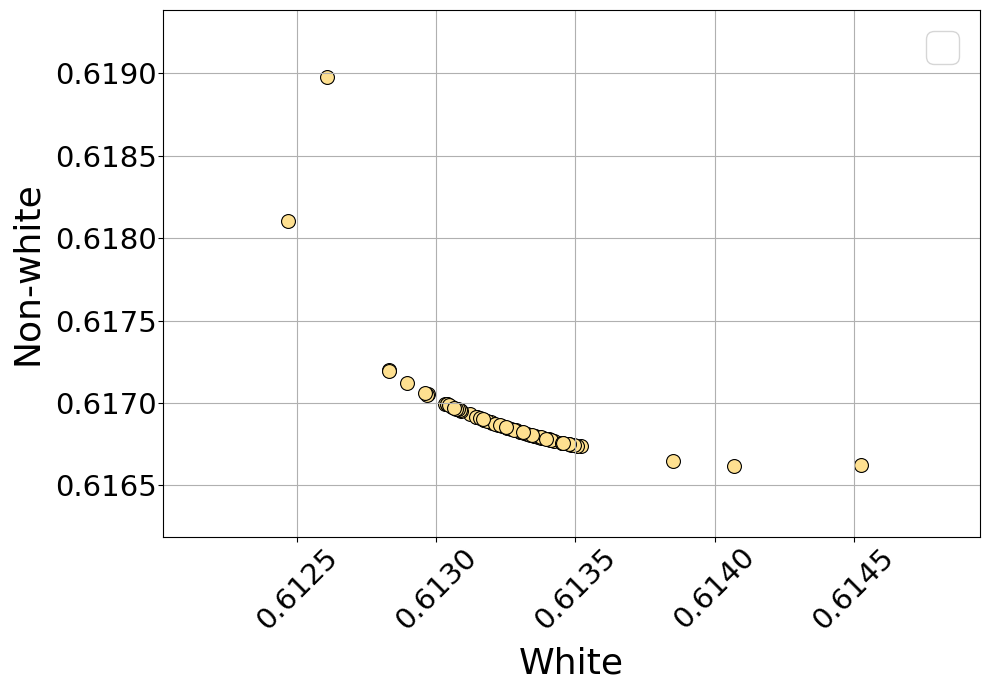

/home/lineccsa/mestrado/machinemoo/machinemoo/analysis/visualization.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=30, loc="upper right")


<Figure size 1000x700 with 0 Axes>

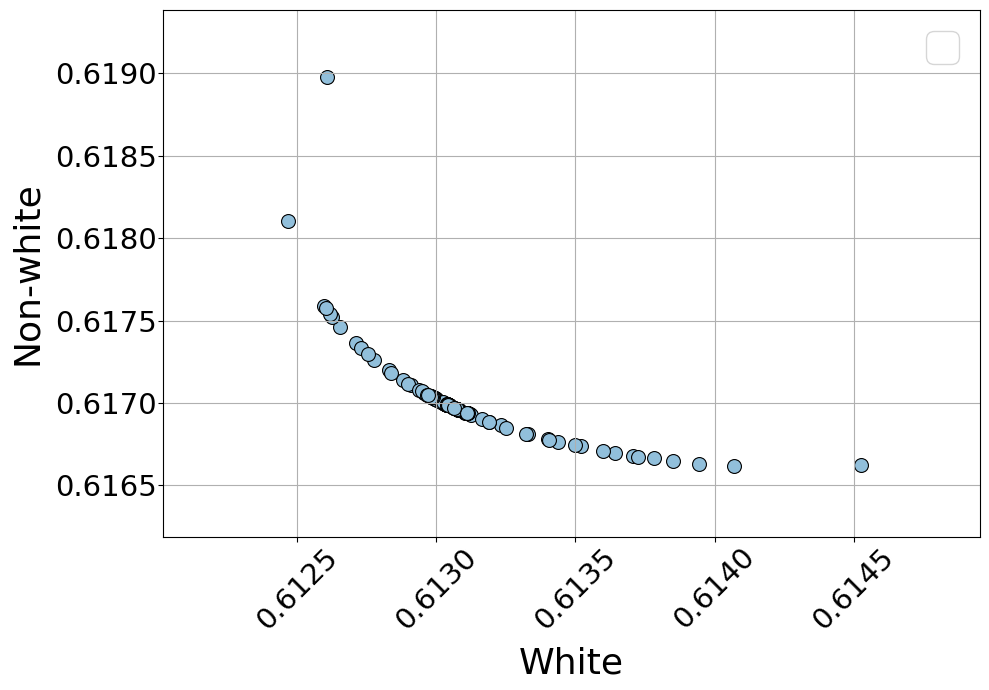

In [ ]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4', '#fee090', '#91bfdb', '#e0f3f8']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )

for i, (method, objs) in enumerate(pareto_dict.items()):
    plot_pareto(methods={method: objs},
                color = color[i],
                labels=objectives_names, 
                #title=title,
                fontsize=26,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}_limit.pdf',
                limits=limits
    )